<a href="https://colab.research.google.com/github/Prathibha-bm/take_it_smart/blob/main/ML_Project_Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Machine Learning Task: House Price Prediction (Regression)**

#**Problem Statement**

The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.

Students are required to analyze the dataset, perform data preprocessing, apply feature
engineering techniques, train multiple regression models, and evaluate their performance to
identify the best model for predicting house prices.


#**Objective**

#The objective of this task is to:

● Understand and explore the housing dataset.

● Perform data preprocessing including handling missing values, duplicates, and outliers.

● Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the
data.

● Apply encoding, log transformation, and feature scaling where necessary.

● Train multiple regression algorithms to predict house prices.

● Evaluate and compare model performance using appropriate evaluation metrics.

# 1.Import Required Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#2. Load the Dataset

In [47]:
df=pd.read_csv("/content/house_price_regression_dataset.csv")
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


#3. Check Dataset

In [7]:
df.shape

(1000, 8)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [9]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [10]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

#4. Handle Missing Values

In [11]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [49]:
df.fillna({col: df[col].median() for col in num_cols}, inplace=True)

In [50]:
# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

#5. Remove Duplicate Records

In [14]:
df.duplicated().sum()


np.int64(0)

In [15]:
df.drop_duplicates(inplace=True)

#6. Univariate Analysi

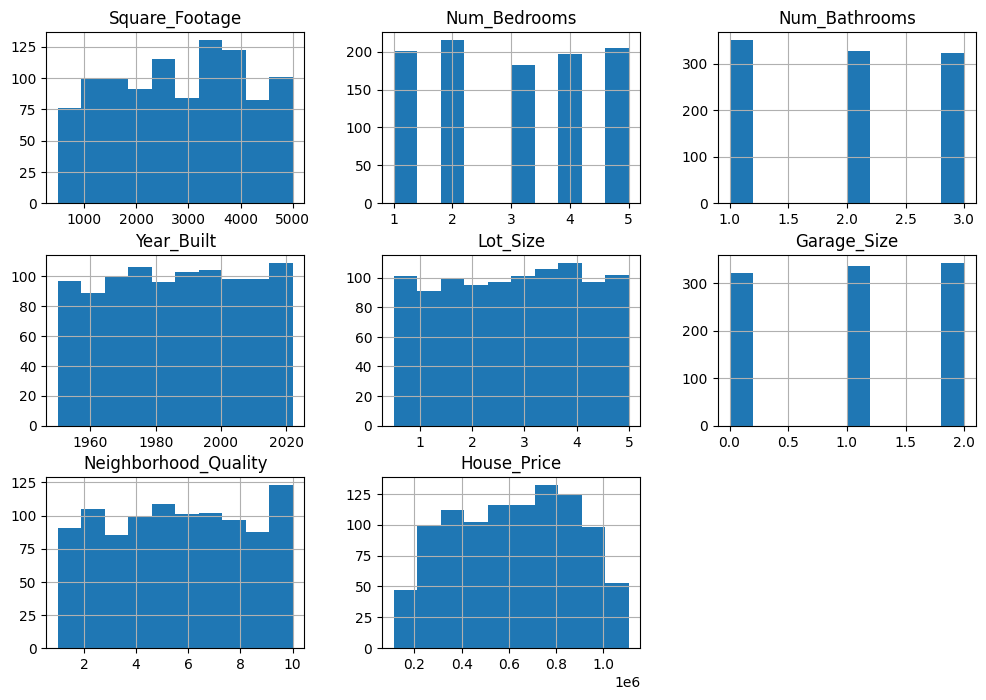

In [16]:
# Histogram
df.hist(figsize=(12,8))
plt.show()

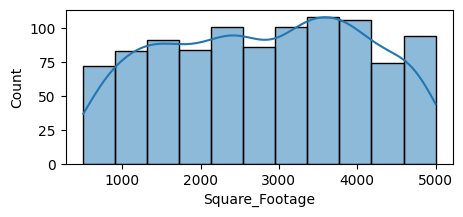

In [17]:
#chech the distribution of Square_Footage

plt.figure(figsize=(5,2))
sns.histplot(df,x='Square_Footage',kde=True)
plt.show()

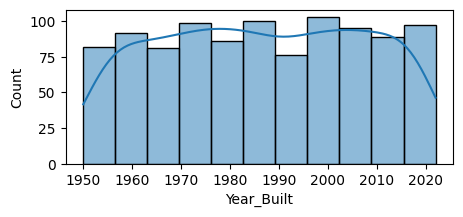

In [18]:
#chech the distribution of Year_Built
plt.figure(figsize=(5,2))
sns.histplot(df,x='Year_Built',kde=True)
plt.show()

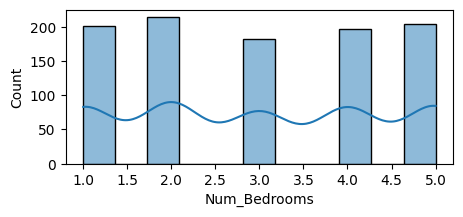

In [19]:
#chech the distribution of Num_Bedrooms
plt.figure(figsize=(5,2))
sns.histplot(df,x='Num_Bedrooms',kde=True)
plt.show()

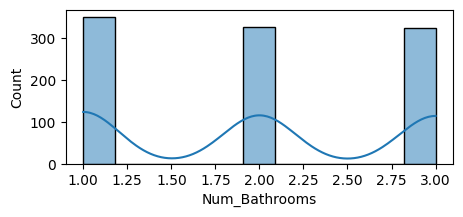

In [20]:
#chech the distribution of Num_Bathrooms
plt.figure(figsize=(5,2))
sns.histplot(df,x='Num_Bathrooms',kde=True)
plt.show()

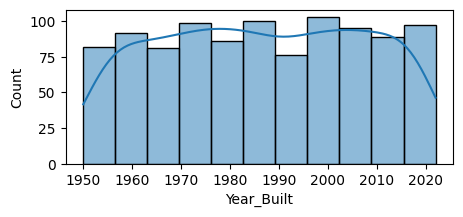

In [21]:
#chech the distribution of Year_Built
plt.figure(figsize=(5,2))
sns.histplot(df,x='Year_Built',kde=True)
plt.show()

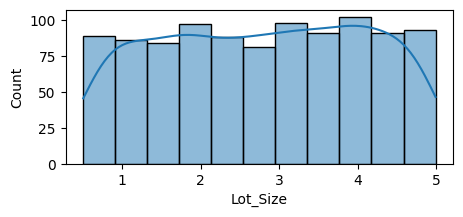

In [22]:
#chech the distribution of Lot_Size
plt.figure(figsize=(5,2))
sns.histplot(df,x='Lot_Size',kde=True)
plt.show()

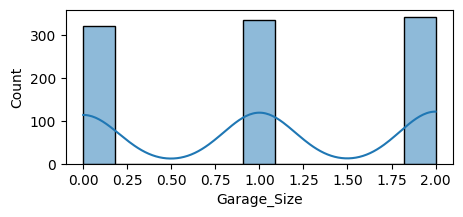

In [23]:
#chech the distribution of Garage_Size
plt.figure(figsize=(5,2))
sns.histplot(df,x='Garage_Size',kde=True)
plt.show()

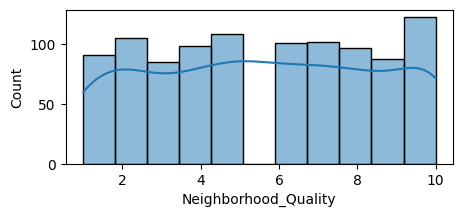

In [24]:
#chech the distribution of Neighborhood_Quality
plt.figure(figsize=(5,2))
sns.histplot(df,x='Neighborhood_Quality',kde=True)
plt.show()

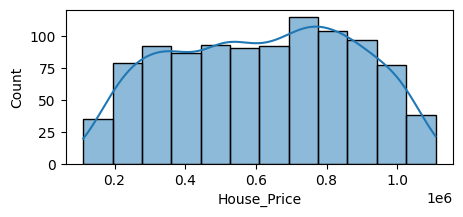

In [25]:
#chech the distribution of House_Price
plt.figure(figsize=(5,2))
sns.histplot(df,x='House_Price',kde=True)
plt.show()

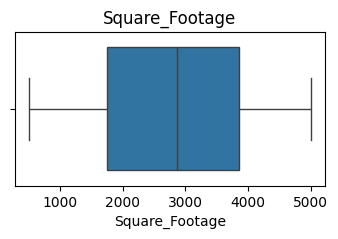

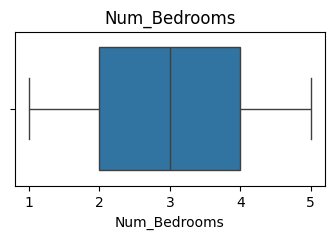

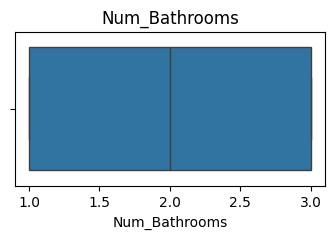

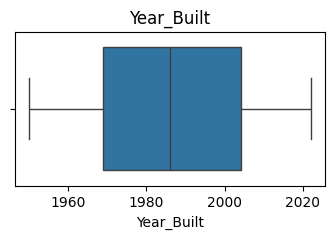

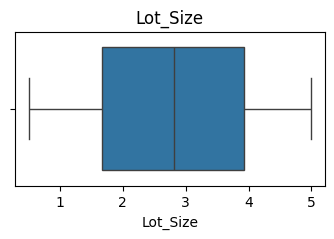

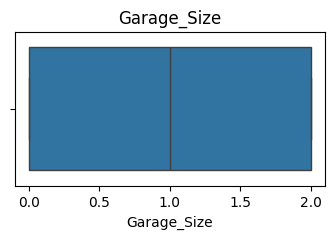

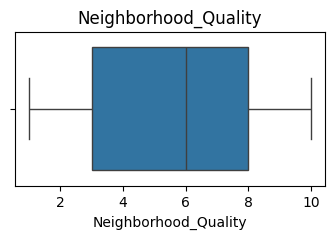

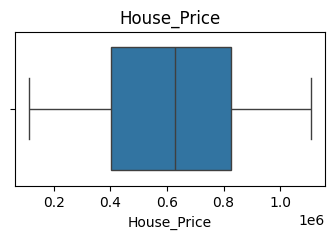

In [26]:
for col in num_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

#7. Bivariate Analysis

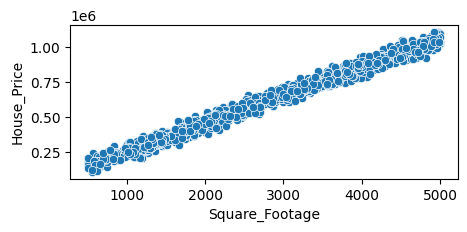

In [27]:
#check the replationship between Square_Footage and House_Price
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Square_Footage',y='House_Price')
plt.show()


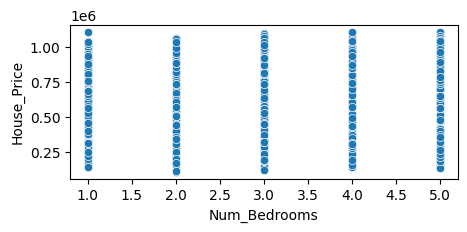

In [28]:
#check the replationship between Num_Bedrooms and House_Price
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Num_Bedrooms',y='House_Price')
plt.show()


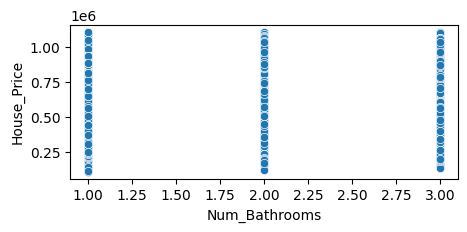

In [29]:
#check the replationship between Num_Bathrooms and House_Price
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Num_Bathrooms',y='House_Price')
plt.show()

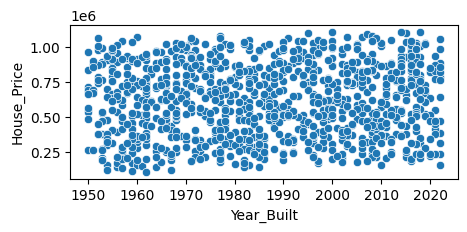

In [30]:
#check the replationship between Year_Built and House_Price
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Year_Built',y='House_Price')
plt.show()

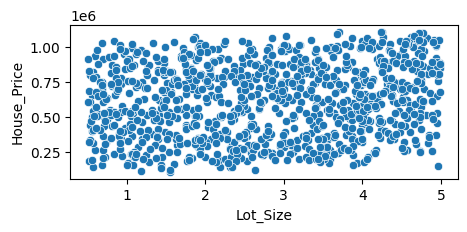

In [31]:
#check the replationship between Lot_Size and House_Price
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Lot_Size',y='House_Price')
plt.show()

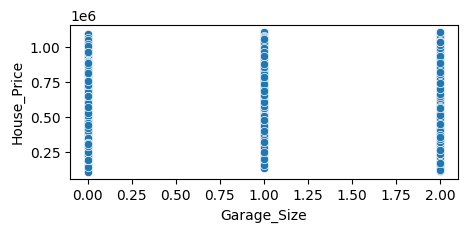

In [32]:
#check the replationship between Garage_Size and House_Price
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Garage_Size',y='House_Price')
plt.show()

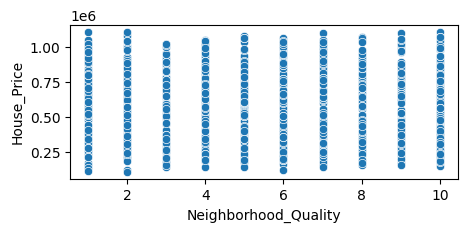

In [33]:
#check the replationship between Neighborhood_Quality and House_Price
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Neighborhood_Quality',y='House_Price')
plt.show()

# 8. Correlation Heatmap

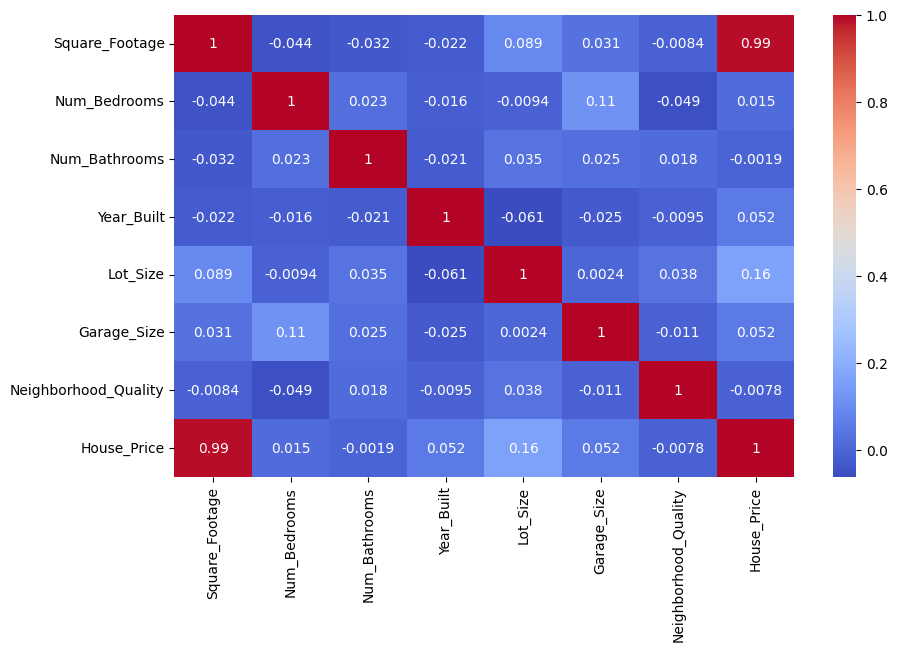

In [34]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

#9. Detect and Handle Outliers

In [35]:
# Using IQR method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

# 10. Encoding (Categorical Data)

In [36]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

#11. Log Transformation

In [37]:
# Apply log to skewed columns (including target if needed)
for col in num_cols:
    df[col] = np.log1p(df[col])

#12. Separate Features and Target

In [38]:
# change if your target column name is different
X=df.drop('House_Price', axis=1)
y=df['House_Price']

#13. Train-Test Split

In [39]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

#14. Feature Scaling

In [40]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#15. Train Models

In [41]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

KNN Regression

In [42]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

# 16. Evaluation Metrics

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_test, y_pred, n_features):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    adj_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - n_features - 1)

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAPE:", mape)
    print("R2 Score:", r2)
    print("Adjusted R2:", adj_r2)

In [44]:
print("KNN Regression Performance")
evaluate(y_test, y_pred_knn, X.shape[1])

KNN Regression Performance
MAE: 0.14258131271091223
MSE: 0.029137830690974677
RMSE: 0.1706980687968516
MAPE: 1.084109037760597
R2 Score: 0.87880764585788
Adjusted R2: 0.8743891746131152


In [45]:
# p: no of columns
p=X_test.shape[1]
p

7

In [46]:
n = X_test.shape[0]
n

200

#Coclusion

The KNN Regression model has performed very well in predicting house prices. The R² score of 0.878 indicates that the model explains about 87.8% of the variance in house prices, which shows strong predictive capability. The Adjusted R² value is also very close, confirming that the model is not overfitting.


Additionally, the error metrics such as MAE, MSE, and RMSE are low, indicating that the difference between actual and predicted values is minimal. The MAPE of around 1% further shows that the prediction error is very small in percentage terms.


Overall, the model provides accurate and reliable predictions for house prices.

#Insights



- The model has successfully captured the relationship between input features and house price.

- Features like Square Footage, Neighborhood Quality, and Lot Size are likely strong contributors to prediction accuracy.

- KNN performed well because it can capture non-linear relationships in the data.

- Feature scaling played an important role in improving KNN performance.